### Import necessary libraries

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,roc_auc_score,roc_curve

### Import the dataset

In [2]:
claiments_dataset = pd.read_csv(filepath_or_buffer="claiments.csv")

In [3]:
claiments_dataset.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


### data understanding

In [5]:
claiments_dataset.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


In [7]:
claiments_dataset.shape

(1340, 7)

In [8]:
claiments_dataset.dtypes

CASENUM       int64
ATTORNEY      int64
CLMSEX      float64
CLMINSUR    float64
SEATBELT    float64
CLMAGE      float64
LOSS        float64
dtype: object

In [9]:
claiments_dataset.isna().sum()

CASENUM       0
ATTORNEY      0
CLMSEX       12
CLMINSUR     41
SEATBELT     48
CLMAGE      189
LOSS          0
dtype: int64

### Data preparation

In [10]:
claiments_dataset.head()

,CASENUM,ATTORNEY,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
0,5,0,0.0,1.0,0.0,50.0,34.940
1,3,1,1.0,0.0,0.0,18.0,0.891
2,66,1,0.0,1.0,0.0,5.0,0.330
3,70,0,0.0,1.0,1.0,31.0,0.037
4,96,1,0.0,1.0,0.0,30.0,0.038


In [12]:
claiments_dataset.dropna(inplace=True)

In [13]:
claiments_dataset.isna().sum()

CASENUM     0
ATTORNEY    0
CLMSEX      0
CLMINSUR    0
SEATBELT    0
CLMAGE      0
LOSS        0
dtype: int64

### Splitting the features into input and output

In [15]:
X = claiments_dataset.drop(labels=['CASENUM',"ATTORNEY"],axis=1)

In [16]:
y = claiments_dataset["ATTORNEY"]

### Model building

In [18]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=101,shuffle=True)

In [19]:
X_train

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
1306,1.0,1.0,0.0,38.0,0.005
58,1.0,1.0,0.0,44.0,0.139
419,0.0,0.0,0.0,50.0,3.719
1172,0.0,1.0,0.0,13.0,0.746
189,1.0,0.0,0.0,65.0,0.373
...,...,...,...,...,...
702,1.0,1.0,0.0,40.0,3.570
1188,1.0,1.0,0.0,44.0,13.000
92,1.0,1.0,0.0,8.0,0.860
729,0.0,1.0,0.0,11.0,0.500


In [20]:
X_test

,CLMSEX,CLMINSUR,SEATBELT,CLMAGE,LOSS
759,0.0,0.0,0.0,30.0,9.909
887,0.0,1.0,0.0,77.0,0.050
1266,1.0,1.0,0.0,37.0,0.193
1083,1.0,1.0,0.0,35.0,1.713
480,0.0,1.0,0.0,47.0,0.090
...,...,...,...,...,...
215,1.0,1.0,0.0,77.0,0.944
257,0.0,1.0,0.0,15.0,3.070
907,0.0,1.0,0.0,39.0,8.815
645,0.0,1.0,0.0,17.0,5.118


In [21]:
y_train

1306    1
58      1
419     0
1172    1
189     1
       ..
702     0
1188    0
92      1
729     1
1060    0
Name: ATTORNEY, Length: 876, dtype: int64

In [22]:
y_test

759     0
887     1
1266    1
1083    1
480     1
       ..
215     1
257     0
907     0
645     0
365     1
Name: ATTORNEY, Length: 220, dtype: int64

In [62]:
decision_tree_model = DecisionTreeClassifier()

### Model training

In [25]:
decision_tree_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Model testing
- 1.Training data
- 2. Testing data

In [26]:
y_pred_train = decision_tree_model.predict(X_train)

In [27]:
y_pred_train

array([1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1,

In [29]:
y_pred_test = decision_tree_model.predict(X_test)

In [30]:
y_pred_test

array([0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1,
       0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0])

### Model evaluation

#### Train data evaluation

In [32]:
accuracy_score(y_train,y_pred_train)

0.997716894977169

In [33]:
confusion_matrix(y_train,y_pred_train)

array([[449,   0],
       [  2, 425]])

In [35]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       449
           1       1.00      1.00      1.00       427

    accuracy                           1.00       876
   macro avg       1.00      1.00      1.00       876
weighted avg       1.00      1.00      1.00       876



0.9976580796252927


Text(0, 0.5, 'True Positive Rate')

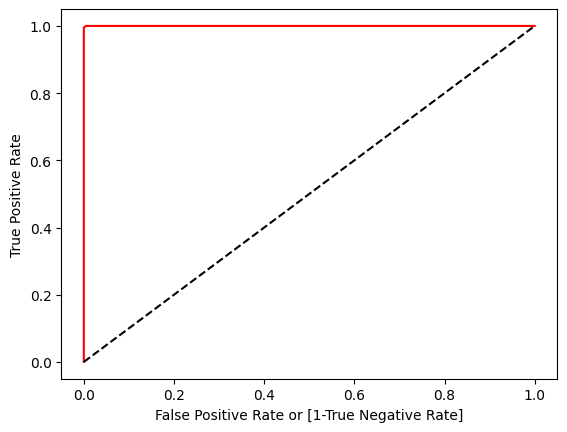

In [36]:
fpr,tpr,thresholds = roc_curve(y_train,decision_tree_model.predict_proba(X_train)[:,1])

auc = roc_auc_score(y_train,y_pred_train)
print(auc)

plt.plot(fpr,tpr,color='red',label = 'Decision Tree Model (area = %0.2f'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel("True Positive Rate")

#### Test data evaluation

In [37]:
accuracy_score(y_test,y_pred_test)

0.5863636363636363

In [38]:
confusion_matrix(y_test,y_pred_test)

array([[81, 48],
       [43, 48]])

In [39]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.65      0.63      0.64       129
           1       0.50      0.53      0.51        91

    accuracy                           0.59       220
   macro avg       0.58      0.58      0.58       220
weighted avg       0.59      0.59      0.59       220



0.5776897521083567


Text(0, 0.5, 'True Positive Rate')

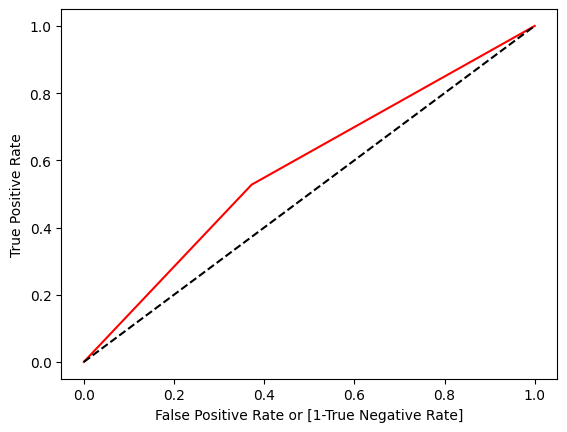

In [40]:
fpr,tpr,thresholds = roc_curve(y_test,decision_tree_model.predict_proba(X_test)[:,1])

auc = roc_auc_score(y_test,y_pred_test)
print(auc)

plt.plot(fpr,tpr,color='red',label = 'Decision Tree model (area = %0.2f'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel("True Positive Rate")

In [41]:
decision_tree_model = DecisionTreeClassifier(max_depth=5)

In [42]:
decision_tree_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
y_pred_train = decision_tree_model.predict(X_train)

In [44]:
y_pred_test = decision_tree_model.predict(X_test)

In [45]:
y_pred_train

array([1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1,
       0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,

In [46]:
y_pred_test

array([0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1,
       1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0])

#### Train

In [47]:
accuracy_score(y_train,y_pred_train)

0.7511415525114156

In [48]:
confusion_matrix(y_train,y_pred_train)

array([[360,  89],
       [129, 298]])

In [49]:
print(classification_report(y_train,y_pred_train))

              precision    recall  f1-score   support

           0       0.74      0.80      0.77       449
           1       0.77      0.70      0.73       427

    accuracy                           0.75       876
   macro avg       0.75      0.75      0.75       876
weighted avg       0.75      0.75      0.75       876



0.7498370044282636


Text(0, 0.5, 'True Positive Rate')

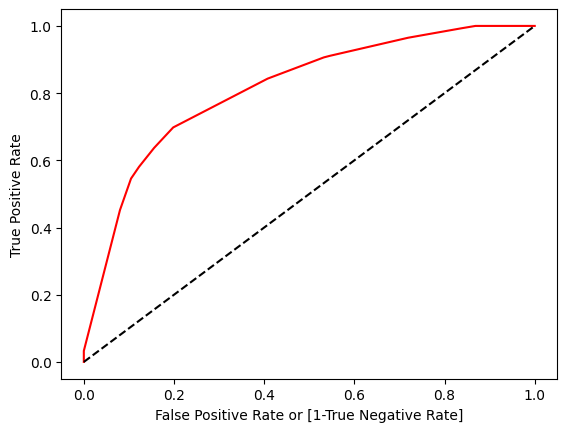

In [50]:
fpr,tpr,thresholds = roc_curve(y_train,decision_tree_model.predict_proba(X_train)[:,1])

auc = roc_auc_score(y_train,y_pred_train)
print(auc)

plt.plot(fpr,tpr,color='red',label = 'Decision Tree Model (area = %0.2f'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel("True Positive Rate")

#### Test

In [51]:
accuracy_score(y_test,y_pred_test)

0.740909090909091

In [52]:
confusion_matrix(y_test,y_pred_test)

array([[99, 30],
       [27, 64]])

In [53]:
print(classification_report(y_test,y_pred_test))

              precision    recall  f1-score   support

           0       0.79      0.77      0.78       129
           1       0.68      0.70      0.69        91

    accuracy                           0.74       220
   macro avg       0.73      0.74      0.73       220
weighted avg       0.74      0.74      0.74       220



0.7353692818809099


Text(0, 0.5, 'True Positive Rate')

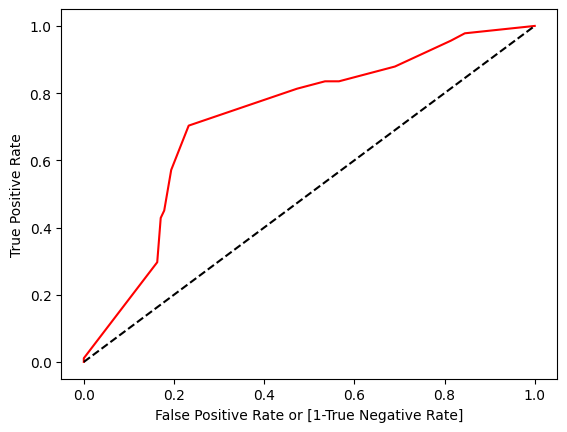

In [54]:
fpr,tpr,thresholds = roc_curve(y_test,decision_tree_model.predict_proba(X_test)[:,1])

auc = roc_auc_score(y_test,y_pred_test)
print(auc)

plt.plot(fpr,tpr,color='red',label = 'Decision Tree model (area = %0.2f'%auc)
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate or [1-True Negative Rate]')
plt.ylabel("True Positive Rate")

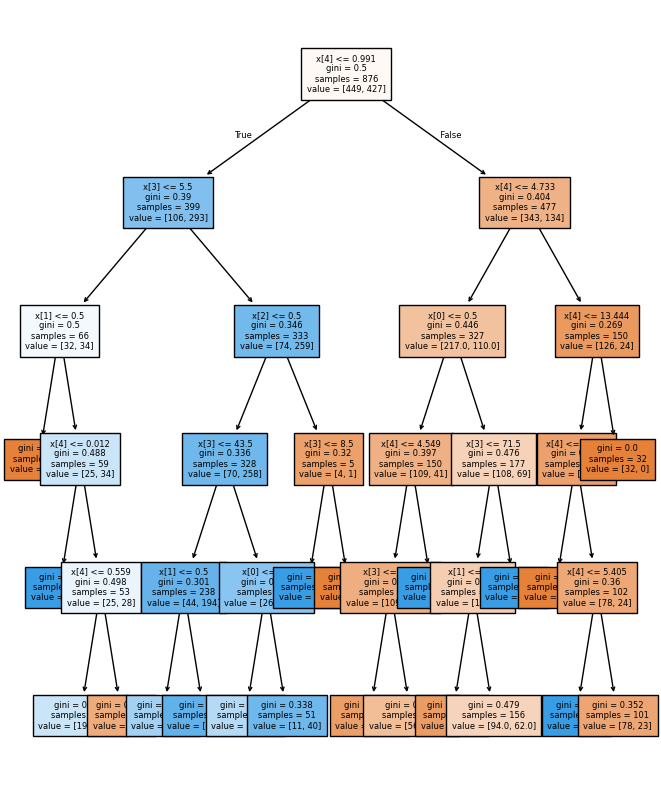

In [60]:
plt.figure(figsize=(8,10))
plot_tree(decision_tree=decision_tree_model,fontsize=6,filled=True)
plt.show()

### GRID search CV - cross validation

In [63]:
grid_search = GridSearchCV(estimator=decision_tree_model,param_grid={"max_depth":[5,6,7,8,9],"criterion":['gini','entropy']})

grid_search.fit(X,y)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [5, 6, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [64]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'gini', 'max_depth': 5}
0.7253507679535076


In [65]:
grid_search = GridSearchCV(estimator=decision_tree_model,param_grid={"max_depth":[5,6,7,8,9],"criterion":['gini','entropy']})

grid_search.fit(X_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [5, 6, ...]}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [66]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'criterion': 'entropy', 'max_depth': 5}
0.7180064935064936
